In [3]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment("customer-churn")

<Experiment: artifact_location='file:c:/Users/LENOVO/OneDrive/Desktop/Machine_Learning_Projects/Customer-Churn-MLOps/notebooks/mlruns/1', creation_time=1789329549732, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789329549732, lifecycle_stage='active', name='customer-churn', tags={}, trace_location=None, workspace='default'>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)


In [5]:
DATA_PATH="../data/raw/WA_fn-UseC_-Telco-Customer-Churn.csv"

In [6]:
df=pd.read_csv(DATA_PATH)

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [9]:
df['TotalCharges'].dtype

dtype('float64')

In [10]:
X=df.drop(columns=['customerID','Churn'])
y=df['Churn'].map({"No":0,"Yes":1})

In [11]:
numeric_features=X.select_dtypes(include=['int64','float64']).columns

categorical_features=X.select_dtypes(include=['str']).columns

In [12]:
numeric_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [13]:
categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [14]:
print("Numerical Features: ")
print(numeric_features.tolist())
print("\nCategorical Features: ")
print(categorical_features.tolist())

Numerical Features: 
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features: 
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [16]:
print("Training distribution: ")
print(y_train.value_counts(normalize=True))
print("\nTesting distribution: ")
print(y_test.value_counts(normalize=True))

Training distribution: 
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing distribution: 
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [17]:
numeric_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy='median')),
    ("scaler",StandardScaler())
])

In [18]:
categorical_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ("encoder",OneHotEncoder(handle_unknown='ignore'))
])

In [19]:
preprocessor=ColumnTransformer([
    ("num",numeric_pipeline,numeric_features),
    ("cat",categorical_pipeline,categorical_features)
])

In [20]:
logistic_model=LogisticRegression(max_iter=1000)

In [21]:
baseline_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",logistic_model)
])

In [22]:
baseline_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [23]:
y_pred=baseline_pipeline.predict(X_test)

In [24]:
baseline_pipeline.predict_proba(X_test)[:5]

array([[0.95470613, 0.04529387],
       [0.31558874, 0.68441126],
       [0.94127926, 0.05872074],
       [0.59829576, 0.40170424],
       [0.97845228, 0.02154772]])

In [25]:
y_prob=baseline_pipeline.predict_proba(X_test)[:,1]

In [26]:
prediction_results=pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":y_pred,
    "Churn_Probability":y_prob
})

In [27]:
prediction_results.head(10)

,Actual,Predicted,Churn_Probability
0,0,0,0.045294
1,0,1,0.684411
2,0,0,0.058721
3,0,0,0.401704
4,0,0,0.021548
5,0,1,0.603935
6,0,0,0.449225
7,0,0,0.130055
8,0,0,0.002881
9,1,0,0.395179


In [28]:
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy: ",accuracy)

Accuracy:  0.8055358410220014


In [29]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[926, 109],
       [165, 209]])

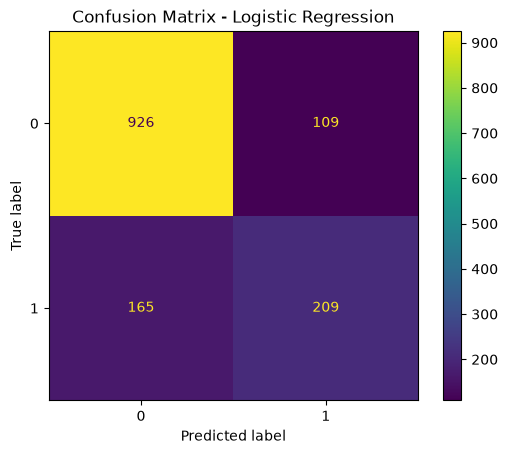

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()



In [31]:
precision=precision_score(y_test,y_pred)
precision

0.6572327044025157

In [32]:
recall=recall_score(y_test,y_pred)
recall

0.5588235294117647

In [33]:
f1=f1_score(y_test,y_pred)

print("F1 Score: ",f1)

F1 Score:  0.6040462427745664


In [34]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.6040


In [35]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [36]:
roc_auc=roc_auc_score(y_test,y_prob)

print("ROC-AUC : ",roc_auc)

ROC-AUC :  0.8418610659019866


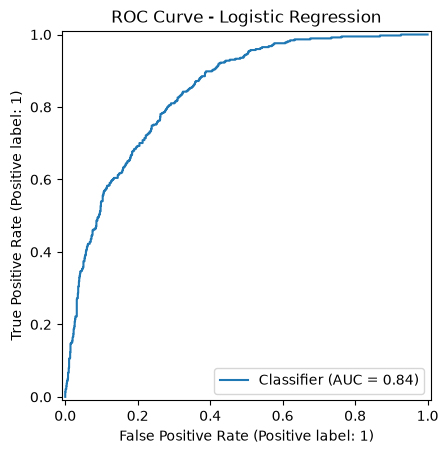

In [37]:
RocCurveDisplay.from_predictions(y_test,y_prob)

plt.title('ROC Curve - Logistic Regression')
plt.show()

In [38]:
baseline_results=pd.DataFrame({
    "Model":["Logistic Regression"],
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1":f1,
    "ROC_AUC":roc_auc
})

baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861


In [39]:
random_forest_model=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [40]:
random_forest_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",random_forest_model)
])

In [41]:
random_forest_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [42]:
rf_y_pred=random_forest_pipeline.predict(X_test)

In [43]:
rf_y_prob=random_forest_pipeline.predict_proba(X_test)[:,1]

In [44]:
rf_accuracy=accuracy_score(y_test,rf_y_pred)
rf_accuracy

0.7757274662881476

In [45]:
rf_precision=precision_score(y_test,rf_y_pred)
rf_precision

0.6

In [46]:
rf_recall=recall_score(y_test,rf_y_pred)
rf_recall

0.46524064171123

In [47]:
rf_f1=f1_score(y_test,rf_y_pred)
rf_f1

0.5240963855421686

In [48]:
rf_roc_auc=roc_auc_score(y_test,rf_y_pred)
rf_roc_auc

0.6765816735126198

In [49]:
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Accuracy : 0.7757
Precision: 0.6000
Recall   : 0.4652
F1 Score : 0.5241
ROC-AUC  : 0.6766


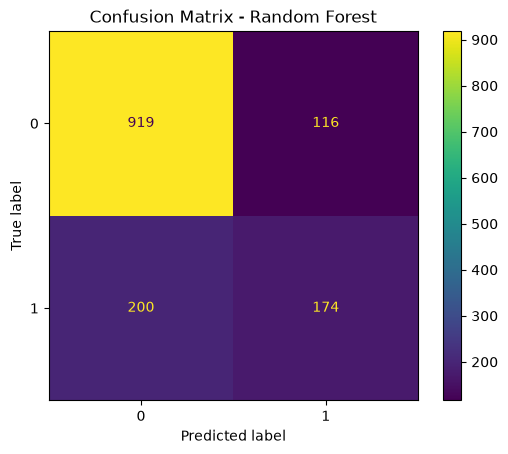

In [50]:
ConfusionMatrixDisplay.from_predictions(y_test,rf_y_pred)

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [51]:
print(
    classification_report(
        y_test,
        rf_y_pred,
        target_names=["No Churn","Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.47      0.52       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



In [52]:
rf_results=pd.DataFrame({
    "Model":["Random Forest"],
    "Accuracy":[rf_accuracy],
    "Precision":[rf_precision],
    "Recall":[rf_recall],
    "F1":[rf_f1],
    "ROC_AUC":[rf_roc_auc]
})

In [53]:
rf_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.775727,0.6,0.465241,0.524096,0.676582


In [54]:
model_comparison=pd.concat([
    baseline_results,
    rf_results
],ignore_index=True
)

In [55]:
model_comparison.reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582


In [56]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582


In [57]:
from xgboost import XGBClassifier

In [58]:
xgb_model=XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

In [59]:
xgb_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",xgb_model)
])

In [60]:
xgb_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [61]:
xgb_y_pred=xgb_pipeline.predict(X_test)


In [62]:
xgb_y_prob=xgb_pipeline.predict_proba(X_test)[:,1]

In [63]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_y_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_y_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_y_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_y_pred
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_y_prob
)

In [64]:
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

Accuracy : 0.8070
Precision: 0.6735
Recall   : 0.5294
F1 Score : 0.5928
ROC-AUC  : 0.8444


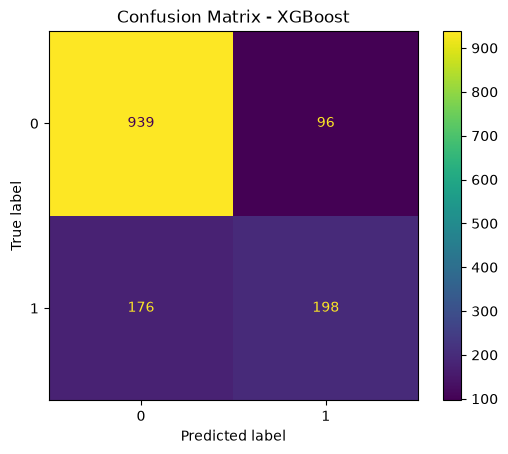

In [65]:
ConfusionMatrixDisplay.from_predictions(y_test,xgb_y_pred)

plt.title("Confusion Matrix - XGBoost")
plt.show()

In [66]:
print(
    classification_report(
            y_test,
            xgb_y_pred,
            target_names=["No Churn","Churn"]
        )

    )

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



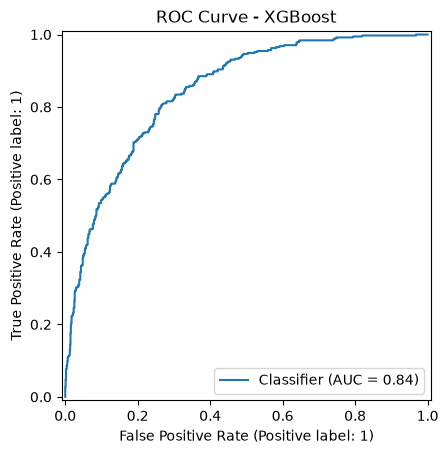

In [67]:
RocCurveDisplay.from_predictions(y_test,xgb_y_prob)

plt.title("ROC Curve - XGBoost")
plt.show()

In [68]:
xgb_results=pd.DataFrame({
    "Model":["XGBoost"],
    "Accuracy":[xgb_accuracy],
    "Precision":[xgb_precision],
    "Recall":[xgb_recall],
    "F1":[xgb_f1],
    "ROC_AUC":[xgb_roc_auc]
    })

In [69]:
xgb_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,0.806955,0.673469,0.529412,0.592814,0.844371


In [70]:
model_comparison=pd.concat([
    baseline_results,
    rf_results,
    xgb_results
],ignore_index=True)

In [71]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582
2,XGBoost,0.806955,0.673469,0.529412,0.592814,0.844371


In [72]:
model_comparison.sort_values(by="ROC_AUC",ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.806955,0.673469,0.529412,0.592814,0.844371
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582


In [73]:
param_distributions={
    "model__n_estimators" : [100,200,300,400],
    "model__learning_rate":[0.01,0.03,0.05,0.1],
    "model__max_depth":[3,4,5,6],
    "model__min_child_weight":[1,3,5],
    "model__subsample" : [0.7,0.8,1.0],
    "model__colsample_bytree":[0.7,0.8,1.0]
}

In [74]:
from sklearn.model_selection import RandomizedSearchCV

In [75]:
random_search=RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [76]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best

In [77]:
random_search.best_params_

{'model__subsample': 0.7,
 'model__n_estimators': 300,
 'model__min_child_weight': 1,
 'model__max_depth': 3,
 'model__learning_rate': 0.03,
 'model__colsample_bytree': 1.0}

In [78]:
random_search.best_score_

np.float64(0.8494087921677679)

In [79]:
best_xgb_pipeline=random_search.best_estimator_

In [80]:
tuned_y_pred=best_xgb_pipeline.predict(X_test)

In [81]:
tuned_y_prob=best_xgb_pipeline.predict_proba(X_test)[:,1]

In [82]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_y_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_y_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_y_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_y_pred
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_y_prob
)

In [83]:
print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1       : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_roc_auc:.4f}")

Accuracy : 0.8062
Precision: 0.6712
Recall   : 0.5294
F1       : 0.5919
ROC-AUC  : 0.8480


In [84]:
tuned_results=pd.DataFrame({
    "Model":["Tuned XGBoost"],
    "Accuracy":[tuned_accuracy],
    "Precision":[tuned_precision],
    "Recall":[tuned_recall],
    "F1":[tuned_f1],
    "ROC_AUC":[tuned_roc_auc]
})

In [85]:
model_comparison=pd.concat([
    baseline_results,
    rf_results,
    xgb_results,
    tuned_results
],ignore_index=True)

In [86]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582
2,XGBoost,0.806955,0.673469,0.529412,0.592814,0.844371
3,Tuned XGBoost,0.806246,0.671186,0.529412,0.591928,0.847963


In [87]:
model_comparison.sort_values(by='ROC_AUC',ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Tuned XGBoost,0.806246,0.671186,0.529412,0.591928,0.847963
2,XGBoost,0.806955,0.673469,0.529412,0.592814,0.844371
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
1,Random Forest,0.775727,0.600000,0.465241,0.524096,0.676582


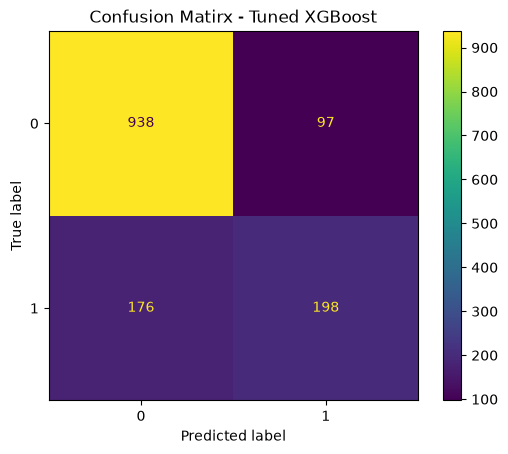

In [88]:
ConfusionMatrixDisplay.from_predictions(y_test,tuned_y_pred)

plt.title("Confusion Matirx - Tuned XGBoost")
plt.show()

In [89]:
print(
    classification_report(
        y_test,
        tuned_y_pred,
        target_names=["No Churn","Churn"]

    )

)

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [90]:
threshold=0.40

custom_y_pred=(tuned_y_prob>=threshold).astype(int)

In [91]:
custom_accuracy = accuracy_score(
    y_test,
    custom_y_pred
)

custom_precision = precision_score(
    y_test,
    custom_y_pred
)

custom_recall = recall_score(
    y_test,
    custom_y_pred
)

custom_f1 = f1_score(
    y_test,
    custom_y_pred
)

print(f"Threshold : {threshold}")
print(f"Accuracy  : {custom_accuracy:.4f}")
print(f"Precision : {custom_precision:.4f}")
print(f"Recall    : {custom_recall:.4f}")
print(f"F1        : {custom_f1:.4f}")

Threshold : 0.4
Accuracy  : 0.7842
Precision : 0.5825
Recall    : 0.6604
F1        : 0.6190


In [92]:
thresholds = [
    0.20, 0.25, 0.30, 0.35, 0.40,
    0.45, 0.50, 0.55, 0.60, 0.65, 0.70
]

threshold_results = []

for threshold in thresholds:

    custom_pred = (
        tuned_y_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            custom_pred
        ),

        "Precision": precision_score(
            y_test,
            custom_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            custom_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            custom_pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.715401,0.479638,0.850267,0.613308
1,0.25,0.743790,0.510888,0.815508,0.628218
2,0.30,0.760114,0.533457,0.767380,0.629386
3,0.35,0.776437,0.561331,0.721925,0.631579
4,0.40,0.784244,0.582547,0.660428,0.619048
5,0.45,0.798439,0.625698,0.598930,0.612022
6,0.50,0.806246,0.671186,0.529412,0.591928
7,0.55,0.806955,0.716102,0.451872,0.554098
8,0.60,0.794890,0.720207,0.371658,0.490300
9,0.65,0.790632,0.765101,0.304813,0.435946


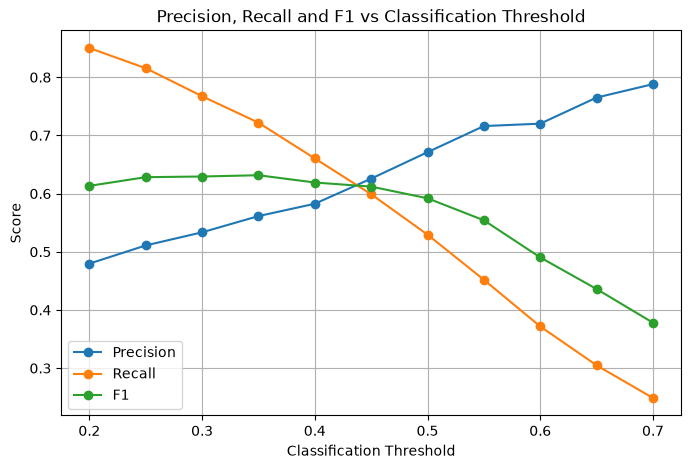

In [93]:
plt.figure(figsize=(8,5))

plt.plot(threshold_df["Threshold"],threshold_df["Precision"],marker='o',label="Precision"),

plt.plot(threshold_df["Threshold"],threshold_df["Recall"],marker="o",label="Recall"),

plt.plot(threshold_df["Threshold"],threshold_df["F1"],marker="o",label="F1")


plt.xlabel("Classification Threshold")

plt.ylabel("Score")

plt.title("Precision, Recall and F1 vs Classification Threshold")

plt.legend()

plt.grid()
plt.show()

In [94]:
from sklearn.metrics import precision_recall_curve

In [95]:
precision,recall,thresholds=precision_recall_curve(y_test,tuned_y_prob)

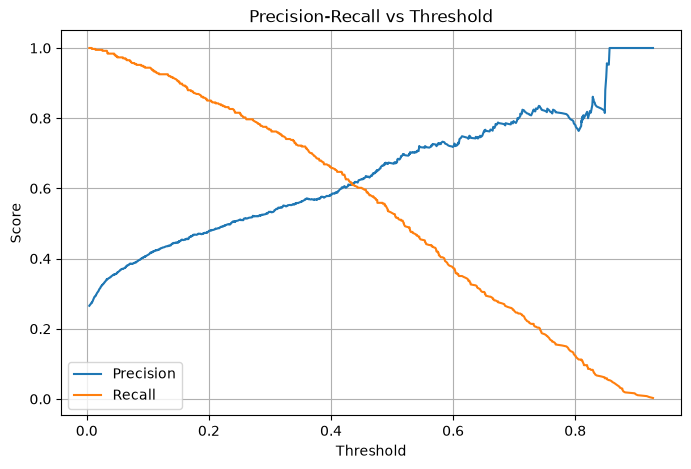

In [96]:
plt.figure(figsize=(8,5))

plt.plot(thresholds,precision[:-1],label="Precision")

plt.plot(thresholds,recall[:-1],label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()

In [97]:
f1_scores=(2*precision[:-1]*recall[:-1]/(precision[:-1]+recall[:-1]+1e-10))


best_index=np.argmax(f1_scores)

best_threshold=thresholds[best_index]
best_f1=f1_scores[best_index]

print("Best Threshold: ",best_threshold)
print("Best F1: ",best_f1)

Best Threshold:  0.35797766
Best F1:  0.6359338060972431


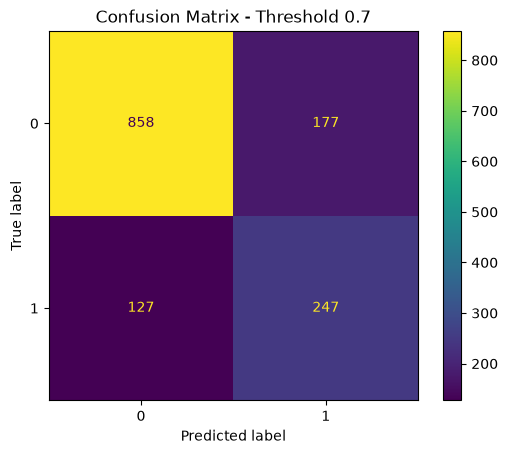

In [98]:
ConfusionMatrixDisplay.from_predictions(y_test,custom_y_pred)

plt.title(f"Confusion Matrix - Threshold {threshold}")
plt.show()


In [99]:
from sklearn.model_selection import StratifiedKFold,cross_val_score

In [100]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [101]:
baseline_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [102]:
lr_cv_scores=cross_val_score(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

In [103]:
print("Fold ROC-AUC scores:")
print(lr_cv_scores)

Fold ROC-AUC scores:
[0.84786648 0.82516399 0.84187226 0.86286616 0.8529156 ]


In [104]:
print("Mean ROC-AUC:", lr_cv_scores.mean())
print("Std ROC-AUC:", lr_cv_scores.std())

Mean ROC-AUC: 0.8461368989751807
Std ROC-AUC: 0.012544801632456264


In [105]:
best_xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [106]:
xgb_cv_scores=cross_val_score(
    best_xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

In [107]:
print("Fold ROC-AUC scores:")
print(xgb_cv_scores)

print("Mean ROC-AUC:", xgb_cv_scores.mean())
print("Std ROC-AUC:", xgb_cv_scores.std())

Fold ROC-AUC scores:
[0.84321531 0.83314753 0.84689303 0.86373459 0.86000089]
Mean ROC-AUC: 0.8493982681935128
Std ROC-AUC: 0.011194083240710407


In [108]:
rf_cv_scores=cross_val_score(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

In [109]:
print("Fold ROC-AUC scores:")
print(rf_cv_scores)

print("Mean ROC-AUC:", rf_cv_scores.mean())
print("Std ROC-AUC:", rf_cv_scores.std())

Fold ROC-AUC scores:
[0.81500533 0.80344304 0.82596174 0.81509218 0.84152536]
Mean ROC-AUC: 0.8202055289630692
Std ROC-AUC: 0.012820597651417293


In [110]:
cv_results=pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Tuned XGBoost"
    ],
    "Mean_ROC_AUC":[
        lr_cv_scores.mean(),
        rf_cv_scores.mean(),
        xgb_cv_scores.mean()
    ],
    "Std_ROC_AUC":[
        lr_cv_scores.std(),
        rf_cv_scores.std(),
        xgb_cv_scores.std()
    ]

})
cv_results

,Model,Mean_ROC_AUC,Std_ROC_AUC
0,Logistic Regression,0.846137,0.012545
1,Random Forest,0.820206,0.012821
2,Tuned XGBoost,0.849398,0.011194


In [111]:
cv_results.sort_values(by="Mean_ROC_AUC",ascending=False)

,Model,Mean_ROC_AUC,Std_ROC_AUC
2,Tuned XGBoost,0.849398,0.011194
0,Logistic Regression,0.846137,0.012545
1,Random Forest,0.820206,0.012821


In [112]:
from sklearn.model_selection import cross_val_predict

In [113]:
oof_prob=cross_val_predict(
    best_xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]

In [114]:
from sklearn.metrics import precision_recall_curve

In [115]:
precision,recall,thresholds=precision_recall_curve(y_train,oof_prob)

In [116]:
f1_scores=(2*precision[:-1]*recall[:-1]/(precision[:-1]+recall[:-1]+1e-10))

In [117]:
thresholds

array([0.00369657, 0.00372308, 0.0037939 , ..., 0.9292352 , 0.9348146 ,
       0.9410506 ], shape=(5605,), dtype=float32)

In [118]:
best_index=np.argmax(f1_scores)


validation_threshold=thresholds[best_index]
validation_f1=f1_scores[best_index]

print("Selected Threshold: ",validation_threshold)
print("Validation F1:",validation_f1)

Selected Threshold:  0.30501002
Validation F1: 0.6381192274912136


In [119]:
final_model=best_xgb_pipeline

final_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [120]:
final_test_prob=final_model.predict_proba(X_test)[:,1]

In [121]:
validation_threshold

np.float32(0.30501002)

In [122]:
final_test_pred=(final_test_prob>=validation_threshold).astype(int)

In [123]:
final_accuracy=accuracy_score(y_test,final_test_pred)

final_precision=precision_score(y_test,final_test_pred,zero_division=0)

final_recall=recall_score(y_test,final_test_pred,zero_division=0)

final_f1=f1_score(y_test,final_test_pred,zero_division=0)

final_roc_auc=roc_auc_score(y_test,final_test_prob)

In [124]:
print("Final Model Performance")
print("-----------------------")
print("Threshold:", validation_threshold)
print("Accuracy:", final_accuracy)
print("Precision:", final_precision)
print("Recall:", final_recall)
print("F1:", final_f1)
print("ROC-AUC:", final_roc_auc)

Final Model Performance
-----------------------
Threshold: 0.30501002
Accuracy: 0.759403832505323
Precision: 0.5327102803738317
Recall: 0.7620320855614974
F1: 0.6270627062706271
ROC-AUC: 0.8479630060192719


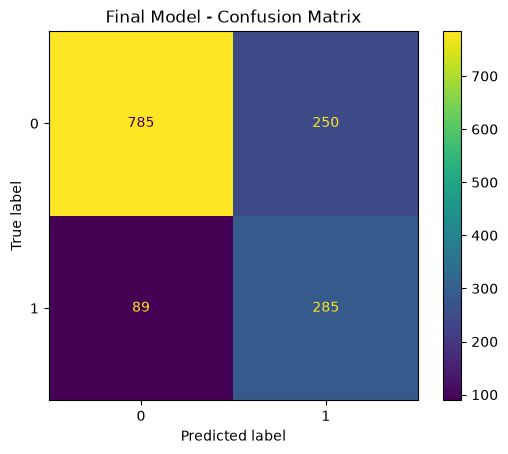

In [125]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_test_pred
)

plt.title("Final Model - Confusion Matrix")
plt.show()

In [126]:
import joblib

In [127]:
joblib.dump(final_model,"../models/customer_churn_model.joblib")

['../models/customer_churn_model.joblib']

In [128]:
import os


print(
    os.path.exists("../models/customer_churn_model.joblib")
)

True


In [129]:
final_artifact={
    "model":final_model,
    "threshold":validation_threshold
}

In [130]:
joblib.dump(final_artifact,"../models/customer_churn_model.joblib")

['../models/customer_churn_model.joblib']

In [131]:
loaded_artifact=joblib.load("../models/customer_churn_model.joblib")

In [132]:
loaded_model=loaded_artifact["model"]
loaded_threshold=loaded_artifact["threshold"]

In [133]:
print("Threshold: ",loaded_threshold)

Threshold:  0.30501002


In [134]:
print("Model: ",loaded_model)

Model:  Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_un...
       

In [135]:
loaded_prob=loaded_model.predict_proba(X_test.iloc[:5])[:,1]


loaded_pred=(loaded_prob>=loaded_threshold).astype(int)

print("Probabilities: ",loaded_prob)
print("Predictions: ",loaded_pred)

Probabilities:  [0.01923041 0.8209271  0.08280276 0.29670665 0.01434618]
Predictions:  [0 1 0 0 0]


In [136]:
final_results=pd.DataFrame({
    "Model":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Score":[
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

final_results

,Model,Score
0,Accuracy,0.759404
1,Precision,0.532710
2,Recall,0.762032
3,F1,0.627063
4,ROC-AUC,0.847963


In [137]:
print("Selected Model: Tuned XGBoost")
print("Selected Threshold:", validation_threshold)

Selected Model: Tuned XGBoost
Selected Threshold: 0.30501002


## Final Model Selection

The tuned XGBoost model was selected as the leading candidate based on its cross-validation performance and overall ranking ability.

Five-fold stratified cross-validation showed that Tuned XGBoost achieved a mean ROC-AUC of 0.8506 with a standard deviation of 0.0114, compared with 0.8461 for Logistic Regression. The difference is relatively small, indicating that Logistic Regression remains a competitive and simpler alternative.

Because the business objective is to identify customers who are likely to churn, recall is also an important consideration. Therefore, classification threshold selection was treated separately from model selection.

To avoid using the test set for threshold optimization, out-of-fold predictions from the training data were used to determine the classification threshold. The selected threshold was then applied to predictions on the untouched test set.

The final Tuned XGBoost pipeline includes both preprocessing and model inference, allowing the same transformations to be applied consistently during future predictions.

The final model artifact and classification threshold were saved together for subsequent deployment through a prediction API.

The test set was used only for final evaluation after model and threshold selection.


In [138]:
import mlflow
import mlflow.sklearn


mlflow.set_experiment("customer-churn")

with mlflow.start_run(run_name="logistic-regression-baseline"):

    # Train
    baseline_pipeline.fit(X_train,y_train)

    # Predict
    y_pred=baseline_pipeline.predict(X_test)
    y_prob=baseline_pipeline.predict_proba(X_test)[:,1]


    # Metrics
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    roc_auc=roc_auc_score(y_test,y_prob)


    # log parameters
    mlflow.log_param("model","Logistic Regression")
    mlflow.log_param("max_iter",1000)

    # log metrics
    mlflow.log_metric("accuracy",accuracy)
    mlflow.log_metric("precision",precision)
    mlflow.log_metric("recall",recall)
    mlflow.log_metric("f1",f1)
    mlflow.log_metric("roc_auc",roc_auc)


    # log model
    mlflow.sklearn.log_model(baseline_pipeline,"model",serialization_format='cloudpickle')

    print("Experiment Logged Successfully.")

2026/09/15 22:32:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 22:32:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Experiment Logged Successfully.
🏃 View run logistic-regression-baseline at: http://127.0.0.1:5000/#/experiments/1/runs/dd1aad2a40b5498388174355e95ede85
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [139]:
with mlflow.start_run(run_name="xgboost-baseline"):

    # train
    xgb_pipeline.fit(X_train,y_train)

    # predict
    y_pred=xgb_pipeline.predict(X_test)
    y_prob=xgb_pipeline.predict_proba(X_test)[:,1]

    # metrics
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    roc_auc=roc_auc_score(y_test,y_prob)


    # log-parameters
    mlflow.log_param("model","XGBoost")
    mlflow.log_param("n_estimators",200)
    mlflow.log_param("learning_rate",0.05)
    mlflow.log_param("max_depth",4)

    # log-metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # log-model
    mlflow.sklearn.log_model(
        xgb_pipeline,
        "model",
        serialization_format="cloudpickle"
    )

2026/09/15 22:32:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 22:32:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run xgboost-baseline at: http://127.0.0.1:5000/#/experiments/1/runs/1a75b451c0cf410a8bdf50511f013858
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [140]:
best_params=random_search.best_params_

In [141]:
with mlflow.start_run(run_name="xgboost-tuned"):

    # Train
    best_xgb_pipeline.fit(X_train, y_train)

    # Predict
    y_prob = best_xgb_pipeline.predict_proba(X_test)[:, 1]

    y_pred = (y_prob >= validation_threshold).astype(int)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Parameters
    mlflow.log_param("model", "Tuned XGBoost")
    mlflow.log_param(
        "classification_threshold",
        validation_threshold
    )

    for parameter, value in best_params.items():
        mlflow.log_param(parameter, value)

    # Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Tags
    mlflow.set_tag("project", "customer-churn")
    mlflow.set_tag("model_type", "XGBoost")
    mlflow.set_tag("model_stage", "candidate")

    # Model
    mlflow.sklearn.log_model(
        best_xgb_pipeline,
        "model",
        serialization_format='cloudpickle'
    )

2026/09/15 22:32:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/15 22:32:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run xgboost-tuned at: http://127.0.0.1:5000/#/experiments/1/runs/457c4f8667824c55b24562ec33fdb103
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [142]:
check_prob=best_xgb_pipeline.predict_proba(X_test)[:,1]

check_auc=roc_auc_score(y_test,check_prob)

print("ROC-AUC:",check_auc)

ROC-AUC: 0.8479630060192719


In [157]:
with mlflow.start_run(run_name="tuned-xgboost-final"):

    # train
    best_xgb_pipeline.fit(X_train,y_train)

    # predictions
    y_pred=best_xgb_pipeline.predict(X_test)
    y_prob=best_xgb_pipeline.predict_proba(X_test)[:,1]

    # metrics
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred,zero_division=0)
    recall=recall_score(y_test,y_pred,zero_division=0)
    f1=f1_score(y_test,y_pred,zero_division=0)
    ruc_auc=roc_auc_score(y_test,y_prob)

    # log parameters
    mlflow.log_param("classification_threshold",validation_threshold)
    mlflow.log_param("model","Tuned_XGBoost")
    for parameter,value in best_params.items():
        mlflow.log_param(parameter,value)


    # log metrics
    mlflow.log_metric("accuracy",accuracy)
    mlflow.log_metric("precision",precision)
    mlflow.log_metric("recall",recall)
    mlflow.log_metric("f1",f1)
    mlflow.log_metric("ruc_auc",roc_auc)


    # tags
    mlflow.set_tag("project","customer-churn")
    mlflow.set_tag("model-type","Tuned XGBoost")
    mlflow.set_tag("status","candidate")

    # input example
    input_example=X_train.head(3)

    # register model
    mlflow.sklearn.log_model(
        best_xgb_pipeline,
        name="model",
        serialization_format='cloudpickle',
        registered_model_name='customer-churn-model',
        input_example=input_example
    )

print("Model registered successfully.")



2026/09/15 23:01:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\LENOVO\OneDrive\Desktop\Machine_Learning_Projects\Customer-Churn-MLOps\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64

🏃 View run tuned-xgboost-final at: http://127.0.0.1:5000/#/experiments/1/runs/57e4ae0935184d62a6968fc75ad90ec3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Model registered successfully.


Created version '2' of model 'customer-churn-model'.


In [158]:
from mlflow import MlflowClient

client=MlflowClient(tracking_uri="http://127.0.0.1:5000")

In [165]:
client.set_registered_model_alias(

        name="customer-churn-model",
        alias='champion',
        version=2
)

print("Champion alias assigned to Version 2.")

Champion alias assigned to Version 2.


In [160]:
model_uri=("models:/customer-churn-model@champion")

champion_model=mlflow.sklearn.load_model(model_uri)

In [161]:
sample_predictions=champion_model.predict(X_test.iloc[:5])

print(sample_predictions)

[0 1 0 0 0]


In [162]:
sample_probabilites=champion_model.predict_proba(X_test.iloc[:5])[:,1]

print(sample_probabilites)

[0.01923041 0.8209271  0.08280276 0.29670665 0.01434618]


In [166]:
from mlflow import MlflowClient

client = MlflowClient(
    tracking_uri="http://127.0.0.1:5000"
)

champion = client.get_model_version_by_alias(
    name="customer-churn-model",
    alias="champion"
)

print("Model Name:", champion.name)
print("Champion Version:", champion.version)
print("Run ID:", champion.run_id)
print("Aliases:", champion.aliases)

Model Name: customer-churn-model
Champion Version: 2
Run ID: 57e4ae0935184d62a6968fc75ad90ec3
Aliases: ['champion']


In [2]:
from mlflow import MlflowClient

client = MlflowClient()

versions = client.search_model_versions("name='customer-churn-model'")
for v in versions:
    print(f"Version: {v.version}, Stage: {v.current_stage}, Run ID: {v.run_id}")


Version: 2, Stage: None, Run ID: 57e4ae0935184d62a6968fc75ad90ec3
Version: 1, Stage: None, Run ID: 7901531542554189ab1a1b1490c573f2


In [3]:
import sys
!{sys.executable} -m pip install pydantic


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
!{sys.executable} -m pip install fastapi uvicorn


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
